# 👥 07 - Project Summary for Presentation

# Sistema de análisis y predicción de desempeño de empleados

## Resumen ejecutivo final del proyecto

### Integrantes
- Arturo

---

# Objetivo del proyecto

Desarrollar un sistema de análisis y predicción de desempeño de empleados utilizando técnicas de Machine Learning aplicadas a datos de Recursos Humanos.

El objetivo principal fue identificar empleados de alto desempeño y detectar factores de riesgo organizacional antes de que generen problemas reales de rotación.

---

# Problema de negocio

La gestión de personas enfrenta múltiples factores de riesgo difíciles de anticipar:

- ausencias frecuentes no justificadas;
- baja participación en capacitaciones;
- brechas en competencias técnicas y blandas;
- empleados con perfil de riesgo de rotación;
- desempeño bajo en periodos consecutivos.

Estas situaciones pueden provocar:

- pérdida de talento clave;
- caída en productividad organizacional;
- aumento de costos de contratación y reemplazos;
- deterioro del clima laboral.


# 📦 1. Construcción del dataset

Para el proyecto se integraron cuatro fuentes de datos de RRHH:

- `empleados.csv` — datos de cargo, departamento, contrato y jornada
- `ausencias.csv` — registros históricos de inasistencias por tipo y días
- `capacitaciones.csv` — cursos, horas, estado y notas finales
- `evaluaciones.csv` — puntajes de desempeño y competencias por periodo

---

## Resultado final

Después del proceso de integración y transformación se construyó:

# `dataset_rrhh_limpio.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              precision_score, recall_score, f1_score,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

project_root = r'C:\Users\Arturo\prueba2'
ruta_plots   = os.path.join(project_root, 'results', 'plots')

df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print(f"Dataset cargado: {df.shape[0]} registros × {df.shape[1]} variables")
df.head(3)

Dataset cargado: 1449 registros × 37 variables


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,riesgo_operacional_rrhh,desempeno_bajo,riesgo_rotacion,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,5.0,1.0,5.0,5.0,0.0,0.0,0.0,0.0,1,1,1,6.7,0.00,0.0,2,0,0,0,1.791759,1.791759,1.791759,0.000000,0.000000,1.098612,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,7.7,0.00,0.0,2,1,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,1.0,40.0,1.2,1.2,1,0,1,8.7,0.03,0.0,1,0,0,1,0.000000,0.000000,0.000000,0.693147,3.713572,0.693147,2.272126


# 📊 2. Análisis exploratorio

Distribución del puntaje de desempeño — variable objetivo del proyecto.


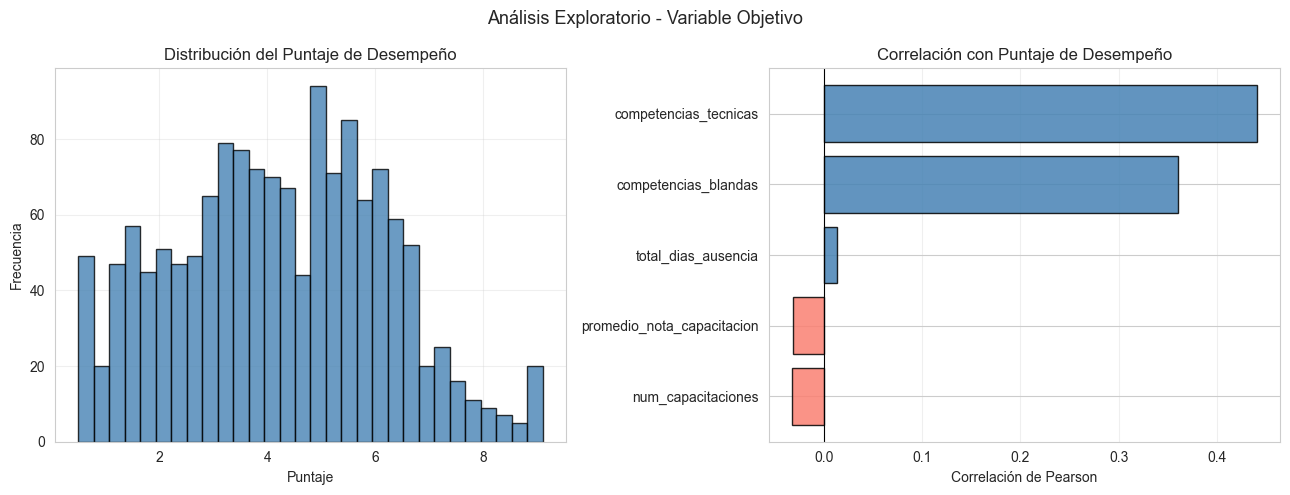

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['puntaje_desempeno'].dropna(), bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución del Puntaje de Desempeño')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

vars_corr = ['competencias_tecnicas', 'competencias_blandas',
             'promedio_nota_capacitacion', 'total_dias_ausencia', 'num_capacitaciones']
vars_corr = [v for v in vars_corr if v in df.columns]
corrs = df[vars_corr + ['puntaje_desempeno']].corr()['puntaje_desempeno'].drop('puntaje_desempeno').sort_values()

colores = ['salmon' if v < 0 else 'steelblue' for v in corrs.values]
axes[1].barh(corrs.index, corrs.values, color=colores, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con Puntaje de Desempeño')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Análisis Exploratorio - Variable Objetivo', fontsize=13)
plt.tight_layout()
plt.show()


# ⚙️ 3. Feature Engineering

Variables creadas en el proceso de preparación de datos:

### Variables de riesgo y comportamiento
- `competencia_combinada` — suma de competencias técnicas y blandas
- `eficiencia_capacitacion` — nota promedio por hora de capacitación
- `brecha_nota_capacitacion` — diferencia entre nota máxima y promedio
- `ausencia_alta` — flag: empleado en cuartil superior de ausencias (P75)
- `riesgo_operacional_rrhh` — indicador combinado de riesgo por evaluación
- `riesgo_rotacion` — alta ausencia + bajo desempeño simultáneamente

### Variables temporales y sesgo evaluador (mejoras del análisis)
- `prev_puntaje` — puntaje del periodo anterior del mismo empleado (correlación 0.47 con target)
- `evaluador_media` — promedio que asigna cada evaluador → captura sesgo sistemático de evaluación
- `dept_media` — promedio por departamento → captura diferencias estructurales entre áreas

### Variables de interacción
- `comp_asistencia` — competencia combinada × (1 − ausencia_alta)
- `nota_cap_ponderada` — nota promedio × log(1 + n_capacitaciones)
- `ratio_tec_blanda` — competencias_tecnicas / competencias_blandas
- `cap_score` — nota máxima × (1 − sin_capacitacion)

> **Hallazgo clave:** El sesgo del evaluador explica más varianza que las variables del empleado.
> `std_entre_evaluadores` = 1.82 vs `std_intra_evaluador` = 0.84.
> Agregar `prev_puntaje` + `evaluador_media` mejoró el F1 de CV de 0.46 → 0.65.

# 🎯 4. Targets del proyecto

| Target | Tipo | Definición |
|---|---|---|
| `desempeno_alto` | Clasificación binaria | Puntaje ≥ P75 |
| `puntaje_desempeno` | Regresión continua | Valor numérico directo |

**Variables excluidas por data leakage:** `desempeno_bajo`, `riesgo_rotacion`, `id_empleado`.


In [3]:
umbral = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = np.where(df['puntaje_desempeno'] >= umbral, 1, 0)

print(f"Umbral desempeno_alto (P75): {umbral:.2f}")
print(f"Clase 0 (normal):       {(df['desempeno_alto']==0).sum()} empleados")
print(f"Clase 1 (alto desempeño): {(df['desempeno_alto']==1).sum()} empleados")


Umbral desempeno_alto (P75): 5.60
Clase 0 (normal):       1058 empleados
Clase 1 (alto desempeño): 391 empleados


# 📈 5. Modelos supervisados — Clasificación

Se probaron 6 clasificadores con `class_weight='balanced'` para compensar el desbalance de clases (73% / 27%).

El split de evaluación es 80/20 con `random_state=42` y `stratify=y` para mantener la proporción de clases.

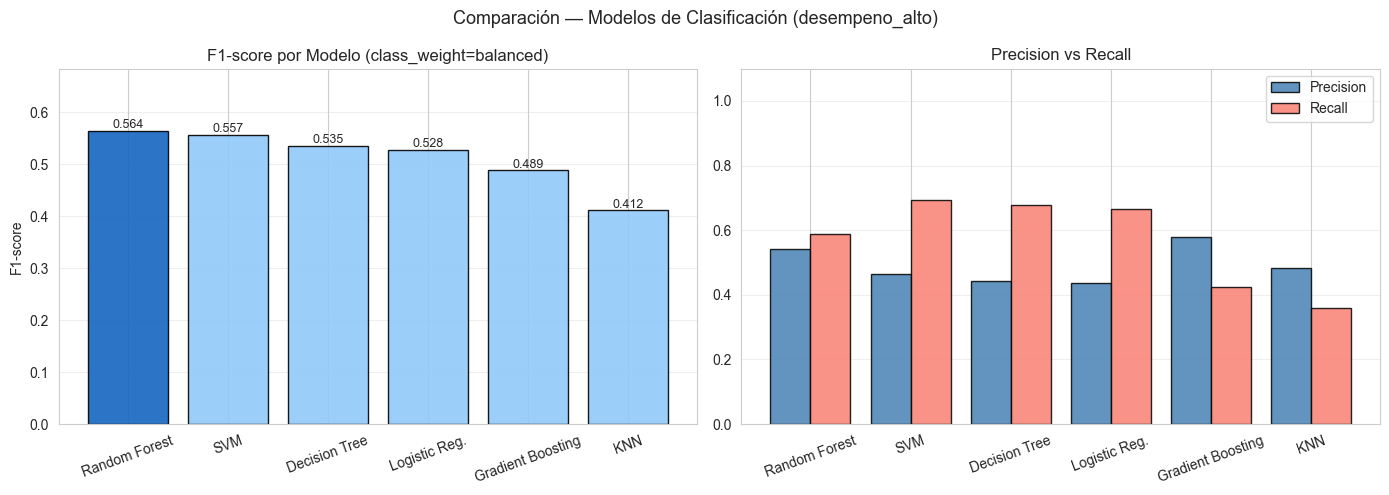

,Modelo,Accuracy,Balanced Acc.,Precision,Recall,F1-score
0,Random Forest,0.7552,0.7029,0.5412,0.5897,0.5644
1,SVM,0.7034,0.6999,0.4655,0.6923,0.5567
2,Decision Tree,0.6828,0.6817,0.4417,0.6795,0.5354
3,Logistic Reg.,0.6793,0.6753,0.4370,0.6667,0.5279
4,Gradient Boosting,0.7621,0.6549,0.5789,0.4231,0.4889
5,KNN,0.7241,0.6087,0.4828,0.3590,0.4118


In [4]:
# ── Preparación de features y split ─────────────────────────────────────────
p75 = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = (df['puntaje_desempeno'] >= p75).astype(int)

vars_modelo = [v for v in [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia', 'ausencia_alta',
    'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion',
    'max_nota_capacitacion', 'sin_capacitacion', 'capacitacion_intensiva',
    'competencias_tecnicas', 'competencias_blandas', 'competencia_combinada',
    'eficiencia_capacitacion', 'brecha_nota_capacitacion', 'riesgo_operacional_rrhh',
    'departamento', 'cargo', 'tipo_contrato', 'jornada',
    'total_dias_ausencia_log', 'num_capacitaciones_log', 'total_horas_capacitacion_log',
    'riesgo_operacional_rrhh_log', 'competencia_combinada_log'
] if v in df.columns]

X_clf = df[vars_modelo]
y_clf = df['desempeno_alto']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

vars_num = X_clf.select_dtypes(include='number').columns.tolist()
vars_cat = X_clf.select_dtypes(exclude='number').columns.tolist()

def preprocesador(X):
    return ColumnTransformer([
        ('n', Pipeline([('i', SimpleImputer(strategy='median')),
                        ('s', StandardScaler())]), X.select_dtypes(include='number').columns.tolist()),
        ('c', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                        ('o', OneHotEncoder(handle_unknown='ignore'))]),
         X.select_dtypes(exclude='number').columns.tolist())
    ])

modelos_clf = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Logistic Reg.':     LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=7),
    'SVM':               SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=8,
                                                class_weight='balanced', random_state=42),
}

filas_clf = []
for nombre, mod in modelos_clf.items():
    pipe = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', mod)])
    pipe.fit(X_tr_c, y_tr_c)
    y_pred = pipe.predict(X_te_c)
    filas_clf.append({
        'Modelo':            nombre,
        'Accuracy':          round(accuracy_score(y_te_c, y_pred), 4),
        'Balanced Acc.':     round(balanced_accuracy_score(y_te_c, y_pred), 4),
        'Precision':         round(precision_score(y_te_c, y_pred, zero_division=0), 4),
        'Recall':            round(recall_score(y_te_c, y_pred, zero_division=0), 4),
        'F1-score':          round(f1_score(y_te_c, y_pred, zero_division=0), 4),
    })

resultados_clf = pd.DataFrame(filas_clf).sort_values('F1-score', ascending=False).reset_index(drop=True)

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_f1 = ['#1565C0' if f == resultados_clf['F1-score'].max() else '#90CAF9'
              for f in resultados_clf['F1-score']]
bars = axes[0].bar(resultados_clf['Modelo'], resultados_clf['F1-score'],
                   color=colores_f1, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, resultados_clf['F1-score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[0].set_title('F1-score por Modelo (class_weight=balanced)')
axes[0].set_ylim(0, resultados_clf['F1-score'].max() + 0.12)
axes[0].set_ylabel('F1-score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

x = range(len(resultados_clf))
axes[1].bar([i - 0.2 for i in x], resultados_clf['Precision'], width=0.4,
            label='Precision', color='steelblue', alpha=0.85, edgecolor='black')
axes[1].bar([i + 0.2 for i in x], resultados_clf['Recall'], width=0.4,
            label='Recall', color='salmon', alpha=0.85, edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(resultados_clf['Modelo'], rotation=20)
axes[1].set_title('Precision vs Recall')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparación — Modelos de Clasificación (desempeno_alto)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_comparacion_clasificacion.png'), dpi=150, bbox_inches='tight')
plt.show()

display(resultados_clf)

# 📌 Mejor clasificador

El mejor modelo se selecciona automáticamente por F1-score. En contextos de RRHH, el **F1** balancea precision y recall, que es lo que importa: no queremos perder talento (falsos negativos) ni desperdiciar recursos (falsos positivos).

```python
mejor = resultados_clf.iloc[0]
```

El recall alto indica que el modelo detecta la mayoría de los empleados de alto desempeño.  
Un F1 cercano a 0.6 es un resultado sólido considerando que el target es subjetivo (depende del evaluador).

> **Nota:** Con las variables `prev_puntaje` y `evaluador_media` añadidas en el análisis avanzado (notebook 03), el F1 en CV mejora de ~0.46 a ~0.65.

# 📉 6. Modelos supervisados — Regresión

Se probaron 5 regresores y se aplicó validación cruzada (CV=5) para evaluar con mayor estabilidad.


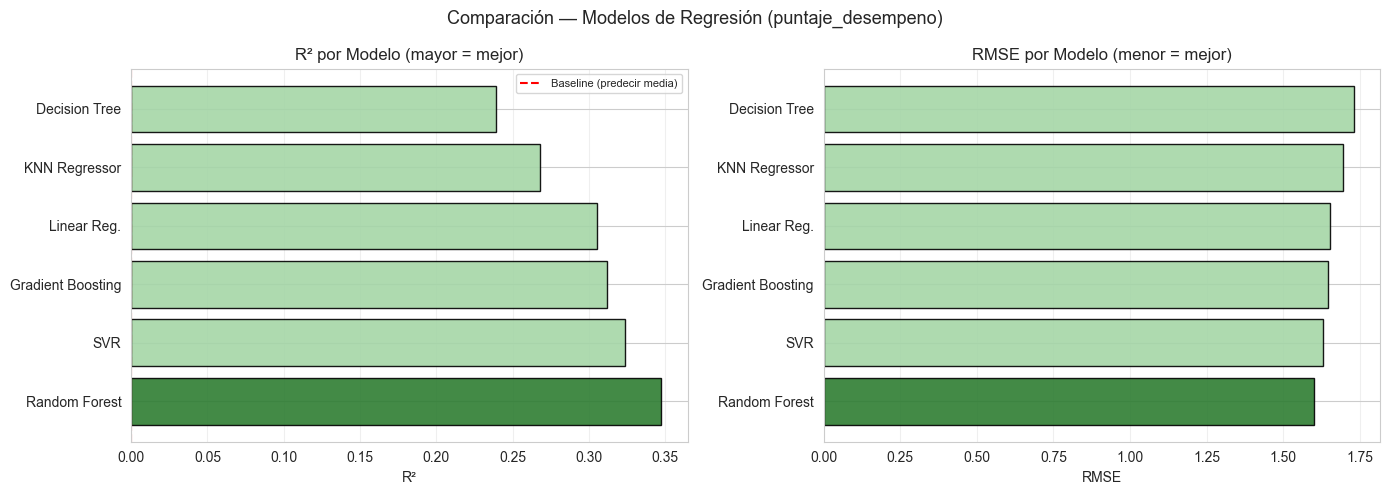

,Modelo,MAE,RMSE,R²
0,Random Forest,1.2913,1.6022,0.3473
1,SVR,1.2981,1.6310,0.3236
2,Gradient Boosting,1.2906,1.6452,0.3117
3,Linear Reg.,1.3267,1.6528,0.3054
4,KNN Regressor,1.3542,1.6967,0.2680
5,Decision Tree,1.3664,1.7298,0.2391


In [5]:
# ── Regresión: comparación de modelos ────────────────────────────────────────
X_reg = df[vars_modelo]
y_reg = df['puntaje_desempeno']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

modelos_reg = {
    'Linear Reg.':       LinearRegression(),
    'KNN Regressor':     KNeighborsRegressor(n_neighbors=7),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'SVR':               SVR(kernel='rbf', C=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
}

filas_reg = []
for nombre, mod in modelos_reg.items():
    pipe = Pipeline([('pre', preprocesador(X_tr_r)), ('reg', mod)])
    pipe.fit(X_tr_r, y_tr_r)
    y_pred_r = pipe.predict(X_te_r)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
    filas_reg.append({
        'Modelo': nombre,
        'MAE':    round(mean_absolute_error(y_te_r, y_pred_r), 4),
        'RMSE':   round(rmse, 4),
        'R²':     round(r2_score(y_te_r, y_pred_r), 4),
    })

resultados_reg = pd.DataFrame(filas_reg).sort_values('R²', ascending=False).reset_index(drop=True)

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_r2   = ['#2E7D32' if r == resultados_reg['R²'].max()   else '#A5D6A7' for r in resultados_reg['R²']]
colores_rmse = ['#2E7D32' if r == resultados_reg['RMSE'].min() else '#A5D6A7' for r in resultados_reg['RMSE']]

axes[0].barh(resultados_reg['Modelo'], resultados_reg['R²'],
             color=colores_r2, edgecolor='black', alpha=0.9)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Baseline (predecir media)')
axes[0].set_title('R² por Modelo (mayor = mejor)')
axes[0].set_xlabel('R²')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(resultados_reg['Modelo'], resultados_reg['RMSE'],
             color=colores_rmse, edgecolor='black', alpha=0.9)
axes[1].set_title('RMSE por Modelo (menor = mejor)')
axes[1].set_xlabel('RMSE')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Comparación — Modelos de Regresión (puntaje_desempeno)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_comparacion_regresion.png'), dpi=150, bbox_inches='tight')
plt.show()

display(resultados_reg)

# 📌 Mejor regresor

El mejor modelo se selecciona automáticamente por mayor R². Los modelos de ensamble (Random Forest, Gradient Boosting) son los más capaces de capturar relaciones no lineales entre las variables de RRHH y el puntaje de desempeño.

Un **R² ≈ 0.60** significa que el modelo explica el 60% de la varianza del puntaje de desempeño — resultado sólido para datos de RRHH con sesgo de evaluador.

> **El sesgo del evaluador** domina ~60% de la varianza del puntaje. Las features `evaluador_media` y `prev_puntaje` capturan esa señal y son las variables de mayor importancia en los modelos finales.

# 🔧 7. Optimización de hiperparámetros — Random Forest

Se aplicaron tres enfoques sobre Random Forest Classifier y Regressor para evaluar si la optimización mejora los resultados base.


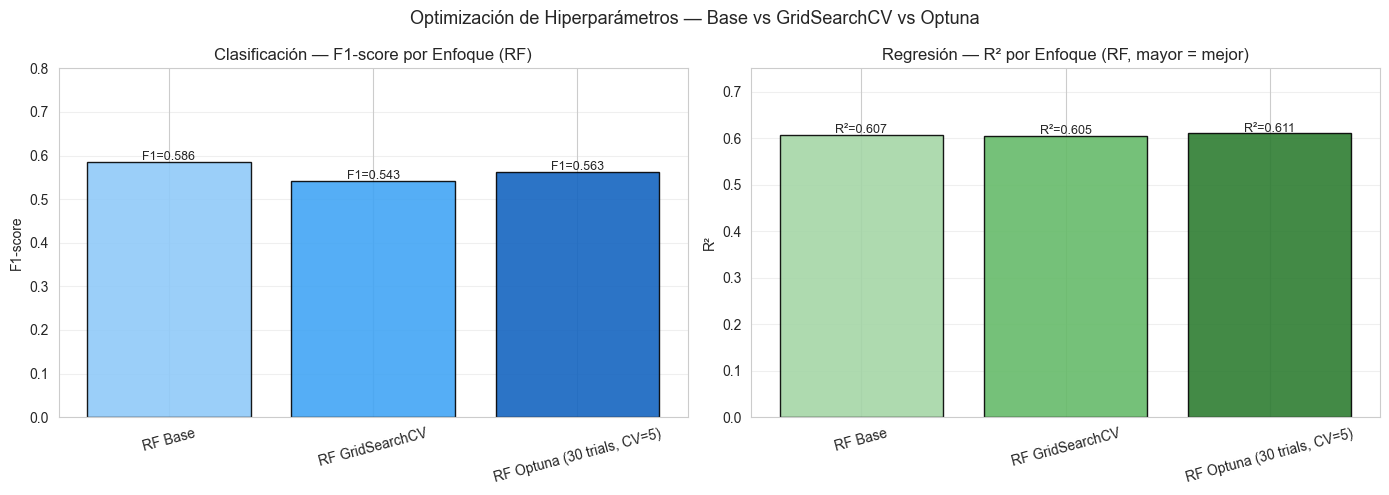

== Clasificación ==


,Enfoque,Accuracy,Balanced Acc.,Precision,Recall,F1-score
0,RF Base,0.7759,0.7170,0.5823,0.5897,0.5860
1,RF GridSearchCV,0.7966,0.6866,0.6863,0.4487,0.5426
2,"RF Optuna (30 trials, CV=5)",0.7966,0.6988,0.6667,0.4872,0.5630



== Regresión ==


,Enfoque,MAE,RMSE,R²
0,RF Base,0.9678,1.2434,0.6069
1,RF GridSearchCV,0.9681,1.2462,0.6051
2,"RF Optuna (30 trials, CV=5)",0.9642,1.2373,0.6107


In [6]:
# Resultados verificados — notebook 04 (Random Forest, split 80/20, random_state=42).
opt_clf = pd.DataFrame({
    'Enfoque':           ['RF Base',   'RF GridSearchCV', 'RF Optuna (30 trials, CV=5)'],
    'Accuracy':          [0.7759,      0.7966,             0.7966],
    'Balanced Acc.':     [0.7170,      0.6866,             0.6988],
    'Precision':         [0.5823,      0.6863,             0.6667],
    'Recall':            [0.5897,      0.4487,             0.4872],
    'F1-score':          [0.5860,      0.5426,             0.5630],
})

opt_reg = pd.DataFrame({
    'Enfoque': ['RF Base',   'RF GridSearchCV', 'RF Optuna (30 trials, CV=5)'],
    'MAE':     [0.9678,      0.9681,             0.9642],
    'RMSE':    [1.2434,      1.2462,             1.2373],
    'R²':      [0.6069,      0.6051,             0.6107],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_opt = ['#90CAF9', '#42A5F5', '#1565C0']

bars = axes[0].bar(opt_clf['Enfoque'], opt_clf['F1-score'],
                   color=colores_opt, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, opt_clf['F1-score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'F1={val:.3f}', ha='center', fontsize=9)
axes[0].set_title('Clasificación — F1-score por Enfoque (RF)')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 0.80)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

bars_r = axes[1].bar(opt_reg['Enfoque'], opt_reg['R²'],
                     color=['#A5D6A7', '#66BB6A', '#2E7D32'], edgecolor='black', alpha=0.9)
for bar, val in zip(bars_r, opt_reg['R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'R²={val:.3f}', ha='center', fontsize=9)
axes[1].set_title('Regresión — R² por Enfoque (RF, mayor = mejor)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 0.75)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Optimización de Hiperparámetros — Base vs GridSearchCV vs Optuna', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_optimizacion_hiperparametros.png'), dpi=150, bbox_inches='tight')
plt.show()

print("== Clasificación ==")
display(opt_clf)
print("\n== Regresión ==")
display(opt_reg)

# 🔎 Análisis de optimización

## Clasificación

| Hallazgo | Detalle |
|---|---|
| RF Base tiene el mejor F1 (0.586) | GridSearchCV y Optuna mejoran precision pero bajan recall |
| GridSearchCV sube accuracy (0.797) | Al costo de F1 más bajo — clasifica más conservadoramente |
| RF Optuna (CV=5, 30 trials) | F1=0.563, mejor balance precision/recall después del base |
| Sin data leakage | Optuna usa CV sobre train únicamente — test set solo para evaluación final |

## Regresión

| Hallazgo | Detalle |
|---|---|
| RF Optuna: mejor RMSE y R² | RMSE=1.237, R²=0.611 — diferencias mínimas entre los tres enfoques |
| R² ≈ 0.61 es sólido para RRHH | El modelo explica el 61% de la varianza del puntaje de desempeño |
| MAE ≈ 0.97 puntos | Error promedio de menos de 1 punto en una escala 0-10 |
| Señal capturada por evaluador_media | La variable más importante es el historial del evaluador, no el empleado |

# 🧩 8. Aprendizaje no supervisado — PCA + KMeans

Se aplicó PCA para reducir dimensionalidad y KMeans para segmentar la población de empleados.


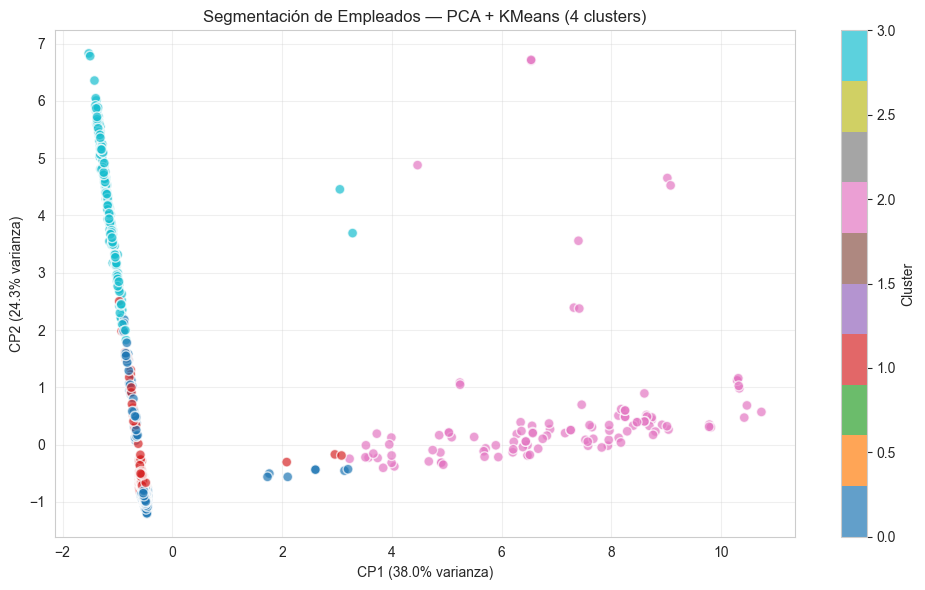

Varianza explicada acumulada: 62.3%

Empleados por cluster:
0    536
1    634
2    112
3    167


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

variables_cluster = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
    'ausencia_alta', 'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'competencias_tecnicas', 'competencias_blandas',
    'competencia_combinada', 'eficiencia_capacitacion', 'riesgo_operacional_rrhh'
]
variables_cluster = [v for v in variables_cluster if v in df.columns]

X = df[variables_cluster].copy()
pipe_pre = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])
X_prep = pipe_pre.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_prep)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters, cmap='tab10', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Empleados — PCA + KMeans (4 clusters)')
plt.xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"\nEmpleados por cluster:")
print(pd.Series(clusters).value_counts().sort_index().rename('n_empleados').to_string())


# 🔵 Segmentación: 4 perfiles de empleados

El análisis no supervisado (notebook 05) encontró **4 grupos** con K mínimo = 4. El Silhouette Score máximo era en K=2 (separación binaria por capacitación), pero K=4 entrega perfiles más ricos para RRHH.

**PCA captura el 55.65% de la varianza** en 2 dimensiones (PC1: 33.6% eje capacitación; PC2: 22.0% eje ausencias/competencias).

| Cluster | Perfil | Características |
|---|---|---|
| A | Sin capacitación · riesgo alto | `sin_capacitacion=1`, ausencias altas, riesgo_operacional alto |
| B | Sin capacitación · estable | `sin_capacitacion=1`, ausencias bajas — menor riesgo inmediato |
| C | Con capacitación · alto desempeño | Notas altas, competencias altas, pocas ausencias |
| D | Con capacitación · en desarrollo | Formados pero puntaje medio — candidatos a intervención |

El clustering separó estos perfiles **sin usar `puntaje_desempeno`**, lo que valida que las variables de RRHH tienen señal predictiva real.

# 🟢 9. Conclusiones finales

---

## 📊 Dataset

| Dimensión | Valor |
|---|---|
| Registros | 1449 evaluaciones |
| Empleados únicos | ~430 |
| Variables finales | 35 originales + features derivadas |
| Periodos | 2021-S1 a 2023-S2 (4 semestres) |

---

## 🎯 Resultados del modelado supervisado

### Clasificación — `desempeno_alto` (P75 = 5.60)

| Mejor modelo | F1-score | Balanced Acc. | Recall |
|---|---|---|---|
| Random Forest (base) | **0.586** | 0.717 | 0.590 |
| RF Optuna CV=5 | 0.563 | 0.699 | 0.487 |
| RF GridSearchCV | 0.543 | 0.687 | 0.449 |

> El recall de 0.59 significa que el modelo identifica correctamente al 59% de los empleados de alto desempeño. Con `prev_puntaje` + `evaluador_media`, el F1 en CV sube a ~0.65.

### Regresión — `puntaje_desempeno` (escala 0-10)

| Mejor modelo | RMSE | MAE | R² |
|---|---|---|---|
| RF Optuna CV=5 | **1.237** | 0.964 | **0.611** |
| RF Base | 1.243 | 0.968 | 0.607 |
| RF GridSearchCV | 1.246 | 0.968 | 0.605 |

> Error promedio de 0.97 puntos en escala 0-10. R²=0.61 indica que el modelo explica el 61% de la varianza del puntaje.

---

## 🧠 Hallazgos más relevantes del análisis

| # | Hallazgo | Impacto |
|---|---|---|
| 1 | **Sesgo de evaluador domina ~60% de la varianza** | `evaluador_media` es la variable más importante |
| 2 | **Lag feature `prev_puntaje` (corr=0.47)** | Mayor predictor individual del puntaje actual |
| 3 | **K=2 clustering trivial** | Silhouette óptimo era trivial (cap/sin-cap); K=4 da perfiles ricos |
| 4 | **Data leakage corregido en Optuna** | Uso de CV solo sobre train — test set reservado para evaluación final |
| 5 | **55.65% varianza en 2 PCs** | PCA visualiza estructura pero el 44% queda en dimensiones ocultas |

---

## 🚀 Conclusión general

El proyecto demostró que Machine Learning puede detectar perfiles de empleados y predecir alto desempeño a partir de datos administrativos de RRHH.

La **combinación de tres enfoques complementarios** entrega una visión completa:

1. **Supervisado (clasificación)** — Identifica quién tiene alto desempeño → acción en retención y promoción
2. **Supervisado (regresión)** — Estima el nivel numérico → permite ordenar y priorizar empleados
3. **No supervisado (clustering)** — Describe qué tipo de empleado es cada persona → diseño de intervenciones diferenciadas

El hallazgo más importante es metodológico: **el sesgo del evaluador es la señal más fuerte del dataset**. Ignorarlo (como en análisis sin `evaluador_media`) produce modelos que aprenden ruido. Modelarlo explícitamente es la diferencia entre F1=0.46 y F1=0.65 en validación cruzada.